# Notebook 26 - Hough peaks, theta resolution, weights, and weighted median

Notebook 25 showed an important clue: the current Python Hough peak list often contains a peak very close to MATLAB `alpha`, but the final Python weighted median is biased higher.

This notebook tests that mechanism directly. It does not modify `ultrasound_tracker`.

What this notebook compares on the same recomputed Python fascicle masks:

1. `thetares=1.0` versus `thetares=0.5`.
2. Current helper peak suppression versus a wider MATLAB-documentation-style neighborhood.
3. Suppressed peaks versus unsuppressed top accumulator bins.
4. Corrected peak weights versus raw Hough weights versus uniform weights.
5. How the sorted weighted cumulative sum crosses 0.5, which is the exact weighted-median decision.

Important limitation: MATLAB's original binary fascicle masks are not saved in the `.mat` file. So this notebook cannot run MATLAB's `houghpeaks` on MATLAB's original mask. Instead, it keeps the **Python mask fixed** and changes only Hough peak/weight/median mechanics. Then it compares those outputs to MATLAB's stored `Fdat.geofeatures.alpha`, `alphas`, and `ws`.

In [1]:
from pathlib import Path
import importlib
from typing import Mapping

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

import ultrasound_tracker.roi as roi
from ultrasound_tracker.legacy.frangi_detector import FrangiDetector
from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_geofeature_arrays,
    get_nested,
    load_matlab_result,
)
from ultrasound_tracker.timtrack_hough import (
    DoHoughParams,
    default_hough_peak_neighborhood,
    ellipse_radius_correction,
    matlab_hough_accumulator,
    matlab_theta_from_range,
    rotate_binary_nearest,
    weighted_median,
)

roi = importlib.reload(roi)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.style.use("default")

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/grosbedou/PycharmProjects/NDORMS


## 1. Inputs and run mode

By default this notebook runs a targeted representative sample: worst frames where the peak exists but the weighted median differs, worst frames where the nearest Python peak is also far, good frames, and regularly spaced frames.

Set `RUN_FULL_SEQUENCE = True` if you want to recompute the variants for all frames. That will be slower because each frame recomputes the Frangi mask and two Hough accumulators.

In [2]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
NB25_DIAGNOSTICS = PROJECT_ROOT / "results" / "matlab_comparison" / "notebook25_alpha_peak_diagnostics.csv"

OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_LONG_CSV = OUT_DIR / "notebook26_hough_variant_frame_metrics.csv"
OUT_SUMMARY_CSV = OUT_DIR / "notebook26_hough_variant_summary.csv"
OUT_NPZ = OUT_DIR / "notebook26_hough_variant_arrays.npz"

RUN_FULL_SEQUENCE = False
N_WEIGHTED_MEDIAN_FAILURES = 25
N_NEAREST_PEAK_FAILURES = 25
N_MATCHED_FRAMES = 20
SPACED_FRAME_STEP = 100

for path in [VIDEO_PATH, ROI_PATH, MATLAB_RESULT, NB25_DIAGNOSTICS]:
    print(path, "exists=", path.exists())

rois = roi.load_rois(ROI_PATH)
mat = load_matlab_result(MATLAB_RESULT)
matlab_geo = extract_geofeature_arrays(mat)
nb25 = pd.read_csv(NB25_DIAGNOSTICS)

print("ROIs:", rois)
print("Notebook 25 rows:", len(nb25))

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 exists= True
/Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json exists= True
/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat exists= True
/Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook25_alpha_peak_diagnostics.csv exists= True
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}
Notebook 25 rows: 2666


## 2. MATLAB stored peaks and frame selection

The MATLAB file stores the final weighted-median `alpha`, plus the peak angle list `alphas` and peak weights `ws`. We use those as the reference ruler.

In [3]:
def as_geofeature_entries(obj):
    if isinstance(obj, Mapping):
        return [obj]
    if isinstance(obj, (list, tuple)):
        return list(obj)
    return list(np.asarray(obj, dtype=object).reshape(-1))


def peak_matrix(entries, key, n_cols=10, fill=np.nan):
    out = np.full((len(entries), n_cols), fill, dtype=np.float64)
    for i, entry in enumerate(entries):
        if not isinstance(entry, Mapping) or key not in entry:
            continue
        values = np.asarray(entry[key], dtype=np.float64).reshape(-1)
        n = min(n_cols, len(values))
        out[i, :n] = values[:n]
    return out


def weighted_median_rows(values, weights):
    out = np.full(values.shape[0], np.nan, dtype=np.float64)
    for i in range(values.shape[0]):
        v = values[i]
        w = weights[i]
        mask = np.isfinite(v) & np.isfinite(w) & (w > 0)
        if np.any(mask):
            out[i] = weighted_median(v[mask], w[mask])
    return out


def nearest_peak(peaks, target):
    target = np.asarray(target, dtype=np.float64)
    nearest_value = np.full(len(target), np.nan, dtype=np.float64)
    nearest_dist = np.full(len(target), np.nan, dtype=np.float64)
    nearest_index = np.full(len(target), -1, dtype=np.int32)
    for i in range(len(target)):
        row = np.asarray(peaks[i], dtype=np.float64)
        mask = np.isfinite(row) & np.isfinite(target[i])
        if not np.any(mask):
            continue
        valid_indices = np.flatnonzero(mask)
        d = np.abs(row[mask] - target[i])
        j_local = int(np.argmin(d))
        j = int(valid_indices[j_local])
        nearest_value[i] = row[j]
        nearest_dist[i] = d[j_local]
        nearest_index[i] = j
    return nearest_value, nearest_dist, nearest_index

entries = as_geofeature_entries(get_nested(mat, "Fdat.geofeatures"))
mat_peak_alphas_all = peak_matrix(entries, "alphas", n_cols=10)
mat_peak_weights_all = peak_matrix(entries, "ws", n_cols=10)
mat_alpha_all = np.asarray(matlab_geo["alpha_deg"], dtype=np.float64)

n_total = min(len(nb25), len(mat_alpha_all), len(mat_peak_alphas_all))
nb25 = nb25.iloc[:n_total].copy()
mat_alpha_all = mat_alpha_all[:n_total]
mat_peak_alphas_all = mat_peak_alphas_all[:n_total]
mat_peak_weights_all = mat_peak_weights_all[:n_total]
mat_alpha_from_peaks_all = weighted_median_rows(mat_peak_alphas_all, mat_peak_weights_all)

if RUN_FULL_SEQUENCE:
    selected_rows = np.arange(n_total, dtype=np.int32)
else:
    weighted_fail = (
        nb25.query("category == 'peak exists, weighted median differs'")
        .sort_values("abs_alpha_error", ascending=False)
        .head(N_WEIGHTED_MEDIAN_FAILURES)["row"]
        .to_numpy(dtype=np.int32)
    )
    nearest_fail = (
        nb25.query("category == 'nearest Python peak also far'")
        .sort_values("abs_alpha_error", ascending=False)
        .head(N_NEAREST_PEAK_FAILURES)["row"]
        .to_numpy(dtype=np.int32)
    )
    matched_pool = nb25.query("category == 'matched within 1 deg'").sort_values("row")
    if len(matched_pool) > N_MATCHED_FRAMES:
        matched_idx = np.linspace(0, len(matched_pool) - 1, N_MATCHED_FRAMES).round().astype(int)
        matched = matched_pool.iloc[matched_idx]["row"].to_numpy(dtype=np.int32)
    else:
        matched = matched_pool["row"].to_numpy(dtype=np.int32)
    spaced = nb25.iloc[::SPACED_FRAME_STEP]["row"].to_numpy(dtype=np.int32)
    selected_rows = np.unique(np.concatenate([weighted_fail, nearest_fail, matched, spaced])).astype(np.int32)

selected_rows = selected_rows[(selected_rows >= 0) & (selected_rows < n_total)]
selected_frames = nb25.loc[selected_rows, "frame"].to_numpy(dtype=np.int32)

print("RUN_FULL_SEQUENCE:", RUN_FULL_SEQUENCE)
print("Selected rows:", len(selected_rows))
print("First 10 selected rows:", selected_rows[:10])
print("First 10 selected frames:", selected_frames[:10])

display(nb25.loc[selected_rows].groupby("category").size().rename("selected_frames").reset_index())

RUN_FULL_SEQUENCE: False
Selected rows: 97
First 10 selected rows: [  0  17  71  72  75  96 100 104 113 114]
First 10 selected frames: [  0  17  71  72  75  96 100 104 113 114]


,category,selected_frames
0,matched within 1 deg,31
1,nearest Python peak also far,25
2,"peak exists, weighted median differs",41


## 3. Local Hough variants

Everything below runs on the same binary mask for a frame. We only change:

- theta step,
- peak suppression neighborhood,
- whether peaks are selected from corrected or raw accumulators,
- whether weights are corrected, raw, or uniform.

The `suspected_matlab_default_nhood` variant uses `2 * ceil(size(H) / 50) + 1`, which is larger than the current helper neighborhood. This is included as a test because peak suppression size directly changes which angle bins enter the weighted median.

In [4]:
def odd_int(value):
    value = max(1, int(value))
    if value % 2 == 0:
        value += 1
    return value


def suspected_matlab_default_nhood(shape):
    return tuple(odd_int(2 * np.ceil(size / 50.0) + 1) for size in shape)


def scaled_nhood(shape, scale):
    base = default_hough_peak_neighborhood(shape)
    return tuple(odd_int(round(v * scale)) for v in base)


def hough_peaks_custom(accumulator, num_peaks, threshold=0.0, neighborhood_size=None, suppress=True):
    h = np.asarray(accumulator, dtype=np.float64).copy()
    if h.ndim != 2 or num_peaks <= 0:
        return np.empty((0, 2), dtype=np.int64)

    if not suppress:
        flat = h.ravel(order="C")
        order = np.argsort(-flat, kind="mergesort")
        out = []
        for flat_index in order:
            value = flat[flat_index]
            if value <= threshold:
                break
            out.append(np.unravel_index(int(flat_index), h.shape))
            if len(out) >= num_peaks:
                break
        return np.asarray(out, dtype=np.int64)

    if neighborhood_size is None:
        neighborhood_size = default_hough_peak_neighborhood(h.shape)

    row_half = int(neighborhood_size[0]) // 2
    col_half = int(neighborhood_size[1]) // 2
    peaks = []
    for _ in range(num_peaks):
        flat_index = int(np.argmax(h))
        value = float(h.flat[flat_index])
        if value <= threshold:
            break
        row, col = np.unravel_index(flat_index, h.shape)
        peaks.append((row, col))
        r0 = max(0, row - row_half)
        r1 = min(h.shape[0], row + row_half + 1)
        c0 = max(0, col - col_half)
        c1 = min(h.shape[1], col + col_half + 1)
        h[r0:r1, c0:c1] = 0.0
    return np.asarray(peaks, dtype=np.int64)


def hough_core(binary, params):
    bw = np.asarray(binary).astype(bool)
    theta = matlab_theta_from_range(params.houghangles, params.angle_range, params.thetares)
    hmat, theta, rho = matlab_hough_accumulator(bw, theta, params.rhores)

    if (
        params.replace_diagonal_bias
        and params.angle_range[0] < 45 < params.angle_range[1]
        and np.any(theta == 45)
    ):
        rot_angle = 20.0
        rotated = rotate_binary_nearest(bw, rot_angle)
        replacement_theta = np.asarray([90.0 - (45.0 + rot_angle)])
        hmat_rot, _, _ = matlab_hough_accumulator(rotated, replacement_theta, params.rhores)
        hmat[:, theta == 45] = hmat_rot

    gamma = 90.0 - theta
    correction = ellipse_radius_correction(gamma, params.emask_radius)
    hcorr = np.rint(hmat / correction[np.newaxis, :])
    return {
        "hmat": hmat,
        "hcorr": hcorr,
        "theta": theta,
        "rho": rho,
        "gamma": gamma,
        "h_by_angle": np.max(hcorr, axis=0) if hcorr.size else np.asarray([]),
    }


def result_from_variant(core, variant, matlab_alpha):
    source = core["hcorr"] if variant["peak_source"] == "corrected" else core["hmat"]
    if variant["nhood"] == "helper":
        nhood = default_hough_peak_neighborhood(source.shape)
        suppress = True
    elif variant["nhood"] == "matlab_doc":
        nhood = suspected_matlab_default_nhood(source.shape)
        suppress = True
    elif variant["nhood"] == "small_1x1":
        nhood = (1, 1)
        suppress = True
    elif variant["nhood"] == "large_3x_helper":
        nhood = scaled_nhood(source.shape, 3.0)
        suppress = True
    elif variant["nhood"] == "none":
        nhood = (1, 1)
        suppress = False
    else:
        raise ValueError(variant["nhood"])

    peaks = hough_peaks_custom(
        source,
        num_peaks=variant.get("npeaks", 10),
        threshold=0.0,
        neighborhood_size=nhood,
        suppress=suppress,
    )

    alphas = np.full(10, np.nan, dtype=np.float64)
    weights = np.full(10, np.nan, dtype=np.float64)
    raw_weights = np.full(10, np.nan, dtype=np.float64)
    corrected_weights = np.full(10, np.nan, dtype=np.float64)

    if len(peaks):
        n = min(10, len(peaks))
        cols = peaks[:n, 1]
        rows = peaks[:n, 0]
        alphas[:n] = core["gamma"][cols]
        raw_weights[:n] = core["hmat"][rows, cols]
        corrected_weights[:n] = core["hcorr"][rows, cols]
        if variant["weight_mode"] == "corrected":
            weights[:n] = corrected_weights[:n]
        elif variant["weight_mode"] == "raw":
            weights[:n] = raw_weights[:n]
        elif variant["weight_mode"] == "uniform":
            weights[:n] = 1.0
        else:
            raise ValueError(variant["weight_mode"])

    mask = np.isfinite(alphas) & np.isfinite(weights) & (weights > 0)
    alpha = weighted_median(alphas[mask], weights[mask]) if np.any(mask) else np.nan
    first_peak_alpha = alphas[0]
    first_peak_weight = weights[0]

    if np.any(np.isfinite(alphas)) and np.isfinite(matlab_alpha):
        d = np.abs(alphas - matlab_alpha)
        nearest_idx = int(np.nanargmin(d))
        nearest_peak = alphas[nearest_idx]
        nearest_dist = d[nearest_idx]
    else:
        nearest_idx = -1
        nearest_peak = np.nan
        nearest_dist = np.nan

    return {
        "alpha": alpha,
        "first_peak_alpha": first_peak_alpha,
        "first_peak_weight": first_peak_weight,
        "total_weight": float(np.nansum(weights)),
        "nearest_peak_to_matlab": nearest_peak,
        "nearest_peak_distance_to_matlab": nearest_dist,
        "nearest_peak_index": nearest_idx,
        "nhood_rows": nhood[0],
        "nhood_cols": nhood[1],
        "suppress": suppress,
        "peaks": peaks,
        "alphas": alphas,
        "weights": weights,
        "raw_weights": raw_weights,
        "corrected_weights": corrected_weights,
    }

variants = [
    {"name": "1deg_helper_corrected", "thetares": 1.0, "nhood": "helper", "peak_source": "corrected", "weight_mode": "corrected", "npeaks": 10},
    {"name": "1deg_matlab_doc_nhood", "thetares": 1.0, "nhood": "matlab_doc", "peak_source": "corrected", "weight_mode": "corrected", "npeaks": 10},
    {"name": "1deg_no_suppression", "thetares": 1.0, "nhood": "none", "peak_source": "corrected", "weight_mode": "corrected", "npeaks": 10},
    {"name": "1deg_small_1x1", "thetares": 1.0, "nhood": "small_1x1", "peak_source": "corrected", "weight_mode": "corrected", "npeaks": 10},
    {"name": "1deg_large_3x_helper", "thetares": 1.0, "nhood": "large_3x_helper", "peak_source": "corrected", "weight_mode": "corrected", "npeaks": 10},
    {"name": "1deg_raw_peak_raw_weight", "thetares": 1.0, "nhood": "helper", "peak_source": "raw", "weight_mode": "raw", "npeaks": 10},
    {"name": "1deg_corrected_peaks_raw_weight", "thetares": 1.0, "nhood": "helper", "peak_source": "corrected", "weight_mode": "raw", "npeaks": 10},
    {"name": "1deg_corrected_peaks_uniform_weight", "thetares": 1.0, "nhood": "helper", "peak_source": "corrected", "weight_mode": "uniform", "npeaks": 10},
    {"name": "0p5deg_helper_corrected", "thetares": 0.5, "nhood": "helper", "peak_source": "corrected", "weight_mode": "corrected", "npeaks": 10},
    {"name": "0p5deg_matlab_doc_nhood", "thetares": 0.5, "nhood": "matlab_doc", "peak_source": "corrected", "weight_mode": "corrected", "npeaks": 10},
]

variant_names = [v["name"] for v in variants]
print("Variants:")
for v in variants:
    print(" -", v)

Variants:
 - {'name': '1deg_helper_corrected', 'thetares': 1.0, 'nhood': 'helper', 'peak_source': 'corrected', 'weight_mode': 'corrected', 'npeaks': 10}
 - {'name': '1deg_matlab_doc_nhood', 'thetares': 1.0, 'nhood': 'matlab_doc', 'peak_source': 'corrected', 'weight_mode': 'corrected', 'npeaks': 10}
 - {'name': '1deg_no_suppression', 'thetares': 1.0, 'nhood': 'none', 'peak_source': 'corrected', 'weight_mode': 'corrected', 'npeaks': 10}
 - {'name': '1deg_small_1x1', 'thetares': 1.0, 'nhood': 'small_1x1', 'peak_source': 'corrected', 'weight_mode': 'corrected', 'npeaks': 10}
 - {'name': '1deg_large_3x_helper', 'thetares': 1.0, 'nhood': 'large_3x_helper', 'peak_source': 'corrected', 'weight_mode': 'corrected', 'npeaks': 10}
 - {'name': '1deg_raw_peak_raw_weight', 'thetares': 1.0, 'nhood': 'helper', 'peak_source': 'raw', 'weight_mode': 'raw', 'npeaks': 10}
 - {'name': '1deg_corrected_peaks_raw_weight', 'thetares': 1.0, 'nhood': 'helper', 'peak_source': 'corrected', 'weight_mode': 'raw', 'npe

## 4. Recompute masks and run variants

For each selected frame:

1. read the video frame,
2. crop the fascicle ROI,
3. recompute the same current Frangi vesselness mask used in notebook 23,
4. compute Hough core once for `thetares=1.0` and once for `thetares=0.5`,
5. apply all peak/weight variants to those cores.

In [5]:
fas_frangi_detector = FrangiDetector(
    sigmas=(1, 2, 4),
    alpha=0.5,
    beta=15.0,
    black_ridges=False,
    threshold=0.08,
    angle_min=10,
    angle_max=70,
    hough_threshold=15,
    min_line_length=25,
    max_line_gap=15,
)

params_by_theta = {
    1.0: DoHoughParams(
        angle_range=(8.0, 80.0),
        thetares=1.0,
        rhores=1.0,
        emask_radius=(rois["fascicle"][3] / 2.0, rois["fascicle"][2] / 2.0),
        npeaks=10,
        replace_diagonal_bias=True,
    ),
    0.5: DoHoughParams(
        angle_range=(8.0, 80.0),
        thetares=0.5,
        rhores=1.0,
        emask_radius=(rois["fascicle"][3] / 2.0, rois["fascicle"][2] / 2.0),
        npeaks=10,
        replace_diagonal_bias=True,
    ),
}


def read_gray_frame(video_path, frame_number):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_number))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Could not read frame {frame_number}")
    if frame.ndim == 3:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return frame.copy()

long_rows = []
alpha_matrix = np.full((len(selected_rows), len(variants)), np.nan, dtype=np.float64)
nearest_matrix = np.full_like(alpha_matrix, np.nan)
first_peak_matrix = np.full_like(alpha_matrix, np.nan)
peak_alpha_cube = np.full((len(selected_rows), len(variants), 10), np.nan, dtype=np.float64)
peak_weight_cube = np.full((len(selected_rows), len(variants), 10), np.nan, dtype=np.float64)
mask_density_by_frame = np.full(len(selected_rows), np.nan, dtype=np.float64)

for i, row_idx in enumerate(selected_rows):
    frame_number = int(nb25.loc[row_idx, "frame"])
    frame_gray = read_gray_frame(VIDEO_PATH, frame_number)
    fas_img = roi.extract_roi(frame_gray, rois["fascicle"])
    vesselness = fas_frangi_detector.get_vesselness_map(fas_img)
    binary = vesselness >= fas_frangi_detector.threshold
    mask_density_by_frame[i] = float(binary.mean())

    cores = {thetares: hough_core(binary, params) for thetares, params in params_by_theta.items()}

    for j, variant in enumerate(variants):
        core = cores[variant["thetares"]]
        result = result_from_variant(core, variant, mat_alpha_all[row_idx])
        alpha_matrix[i, j] = result["alpha"]
        nearest_matrix[i, j] = result["nearest_peak_distance_to_matlab"]
        first_peak_matrix[i, j] = result["first_peak_alpha"]
        peak_alpha_cube[i, j, :] = result["alphas"]
        peak_weight_cube[i, j, :] = result["weights"]

        long_rows.append({
            "selected_index": i,
            "row": int(row_idx),
            "frame": frame_number,
            "category_nb25": nb25.loc[row_idx, "category"],
            "variant": variant["name"],
            "thetares": variant["thetares"],
            "nhood": variant["nhood"],
            "peak_source": variant["peak_source"],
            "weight_mode": variant["weight_mode"],
            "nhood_rows": result["nhood_rows"],
            "nhood_cols": result["nhood_cols"],
            "suppress": result["suppress"],
            "mask_density": mask_density_by_frame[i],
            "matlab_alpha": mat_alpha_all[row_idx],
            "matlab_alpha_from_saved_peaks": mat_alpha_from_peaks_all[row_idx],
            "variant_alpha": result["alpha"],
            "variant_error": result["alpha"] - mat_alpha_all[row_idx],
            "abs_variant_error": abs(result["alpha"] - mat_alpha_all[row_idx]) if np.isfinite(result["alpha"]) else np.nan,
            "first_peak_alpha": result["first_peak_alpha"],
            "first_peak_weight": result["first_peak_weight"],
            "total_weight": result["total_weight"],
            "nearest_peak_to_matlab": result["nearest_peak_to_matlab"],
            "nearest_peak_distance_to_matlab": result["nearest_peak_distance_to_matlab"],
            "nearest_peak_index": result["nearest_peak_index"],
        })

    if (i + 1) % 10 == 0 or (i + 1) == len(selected_rows):
        print(f"Processed {i + 1}/{len(selected_rows)} selected frames")

variant_df = pd.DataFrame(long_rows)
variant_df.to_csv(OUT_LONG_CSV, index=False)
print("Saved long variant table:", OUT_LONG_CSV)

display(variant_df.head())

Processed 10/97 selected frames


Processed 20/97 selected frames


Processed 30/97 selected frames


Processed 40/97 selected frames


Processed 50/97 selected frames


...

Processed 70/97 selected frames


Processed 80/97 selected frames


Processed 90/97 selected frames


Processed 97/97 selected frames
Saved long variant table: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook26_hough_variant_frame_metrics.csv


,selected_index,row,frame,category_nb25,variant,thetares,nhood,peak_source,weight_mode,nhood_rows,nhood_cols,suppress,mask_density,matlab_alpha,matlab_alpha_from_saved_peaks,variant_alpha,variant_error,abs_variant_error,first_peak_alpha,first_peak_weight,total_weight,nearest_peak_to_matlab,nearest_peak_distance_to_matlab,nearest_peak_index
0,0,0,0,"peak exists, weighted median differs",1deg_helper_corrected,1.0,helper,corrected,corrected,29,3,True,0.084122,18.5,18.5,24.0,5.5,5.5,19.0,264.0,2170.0,19.0,0.5,0
1,0,0,0,"peak exists, weighted median differs",1deg_matlab_doc_nhood,1.0,matlab_doc,corrected,corrected,59,5,True,0.084122,18.5,18.5,22.0,3.5,3.5,19.0,264.0,2082.0,19.0,0.5,0
2,0,0,0,"peak exists, weighted median differs",1deg_no_suppression,1.0,none,corrected,corrected,1,1,False,0.084122,18.5,18.5,25.0,6.5,6.5,19.0,264.0,2382.0,19.0,0.5,0
3,0,0,0,"peak exists, weighted median differs",1deg_small_1x1,1.0,small_1x1,corrected,corrected,1,1,True,0.084122,18.5,18.5,25.0,6.5,6.5,19.0,264.0,2382.0,19.0,0.5,0
4,0,0,0,"peak exists, weighted median differs",1deg_large_3x_helper,1.0,large_3x_helper,corrected,corrected,87,9,True,0.084122,18.5,18.5,21.0,2.5,2.5,19.0,264.0,1971.0,19.0,0.5,0


## 5. Summary metrics

This is the core table. Lower MAE means the variant moves the final weighted-median alpha closer to MATLAB alpha on the selected frames.

The `nearest_peak_mae` column is the best possible error if we were allowed to choose the closest peak to MATLAB. It is not an algorithm, but it tells us whether the variant peak list contains the right neighborhood.

In [6]:
def metric_dict(reference, estimate):
    out = compute_metrics(reference, estimate)
    return {k: out[k] for k in ["n", "bias", "mae", "rmse", "corr"]}

summary_rows = []
for name in variant_names:
    sub = variant_df[variant_df["variant"] == name].copy()
    m_alpha = metric_dict(sub["matlab_alpha"].to_numpy(), sub["variant_alpha"].to_numpy())
    m_first = metric_dict(sub["matlab_alpha"].to_numpy(), sub["first_peak_alpha"].to_numpy())
    summary_rows.append({
        "variant": name,
        "thetares": sub["thetares"].iloc[0],
        "nhood": sub["nhood"].iloc[0],
        "peak_source": sub["peak_source"].iloc[0],
        "weight_mode": sub["weight_mode"].iloc[0],
        "nhood_rows": sub["nhood_rows"].iloc[0],
        "nhood_cols": sub["nhood_cols"].iloc[0],
        "alpha_bias": m_alpha["bias"],
        "alpha_mae": m_alpha["mae"],
        "alpha_rmse": m_alpha["rmse"],
        "alpha_corr": m_alpha["corr"],
        "first_peak_mae": m_first["mae"],
        "nearest_peak_mae": float(np.nanmean(sub["nearest_peak_distance_to_matlab"])),
        "pct_alpha_within_1deg": float(np.nanmean(sub["abs_variant_error"] <= 1.0)),
        "pct_peak_within_1deg": float(np.nanmean(sub["nearest_peak_distance_to_matlab"] <= 1.0)),
    })

summary = pd.DataFrame(summary_rows).sort_values("alpha_mae")
summary.to_csv(OUT_SUMMARY_CSV, index=False)
display(summary)
print("Saved summary:", OUT_SUMMARY_CSV)

np.savez(
    OUT_NPZ,
    selected_rows=selected_rows,
    selected_frames=selected_frames,
    variant_names=np.asarray(variant_names),
    matlab_alpha=mat_alpha_all[selected_rows],
    matlab_peak_alphas=mat_peak_alphas_all[selected_rows],
    matlab_peak_weights=mat_peak_weights_all[selected_rows],
    alpha_matrix=alpha_matrix,
    nearest_peak_distance_matrix=nearest_matrix,
    first_peak_matrix=first_peak_matrix,
    peak_alpha_cube=peak_alpha_cube,
    peak_weight_cube=peak_weight_cube,
    mask_density=mask_density_by_frame,
)
print("Saved arrays:", OUT_NPZ)

,variant,thetares,nhood,peak_source,weight_mode,nhood_rows,nhood_cols,alpha_bias,alpha_mae,alpha_rmse,alpha_corr,first_peak_mae,nearest_peak_mae,pct_alpha_within_1deg,pct_peak_within_1deg
5,1deg_raw_peak_raw_weight,1.0,helper,raw,raw,29,3,-5.164948,5.896907,7.963836,0.369116,8.257732,0.773196,0.216495,0.865979
6,1deg_corrected_peaks_raw_weight,1.0,helper,corrected,raw,29,3,6.577320,6.793814,8.779663,0.356039,7.525773,1.536082,0.340206,0.742268
7,1deg_corrected_peaks_uniform_weight,1.0,helper,corrected,uniform,29,3,6.567010,6.793814,8.779663,0.352571,7.525773,1.536082,0.340206,0.742268
1,1deg_matlab_doc_nhood,1.0,matlab_doc,corrected,corrected,59,5,6.659794,6.804124,8.848088,0.358594,7.525773,1.020619,0.340206,0.773196
4,1deg_large_3x_helper,1.0,large_3x_helper,corrected,corrected,87,9,6.731959,6.814433,8.828258,0.382151,7.525773,0.876289,0.340206,0.762887
9,0p5deg_matlab_doc_nhood,0.5,matlab_doc,corrected,corrected,59,7,6.778351,6.963918,8.922201,0.357259,7.530928,1.144330,0.309278,0.773196
8,0p5deg_helper_corrected,0.5,helper,corrected,corrected,29,3,7.077320,7.170103,9.219125,0.324422,7.530928,2.835052,0.329897,0.618557
0,1deg_helper_corrected,1.0,helper,corrected,corrected,29,3,7.072165,7.216495,9.262495,0.311600,7.525773,1.536082,0.319588,0.742268
2,1deg_no_suppression,1.0,none,corrected,corrected,1,1,7.350515,7.402062,9.432342,0.333625,7.525773,6.082474,0.278351,0.412371
3,1deg_small_1x1,1.0,small_1x1,corrected,corrected,1,1,7.350515,7.402062,9.432342,0.333625,7.525773,6.082474,0.278351,0.412371


Saved summary: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook26_hough_variant_summary.csv
Saved arrays: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook26_hough_variant_arrays.npz


In [7]:
display(Markdown(f"""
**Best variant on selected frames:** `{summary.iloc[0]['variant']}` with alpha MAE **{summary.iloc[0]['alpha_mae']:.3f} deg**.

**Current notebook 23 equivalent:** `1deg_helper_corrected` has alpha MAE **{summary.loc[summary['variant'] == '1deg_helper_corrected', 'alpha_mae'].iloc[0]:.3f} deg** on the same selected frames.
"""))


**Best variant on selected frames:** `1deg_raw_peak_raw_weight` with alpha MAE **5.897 deg**.

**Current notebook 23 equivalent:** `1deg_helper_corrected` has alpha MAE **7.216 deg** on the same selected frames.


## 6. Variant comparison plots

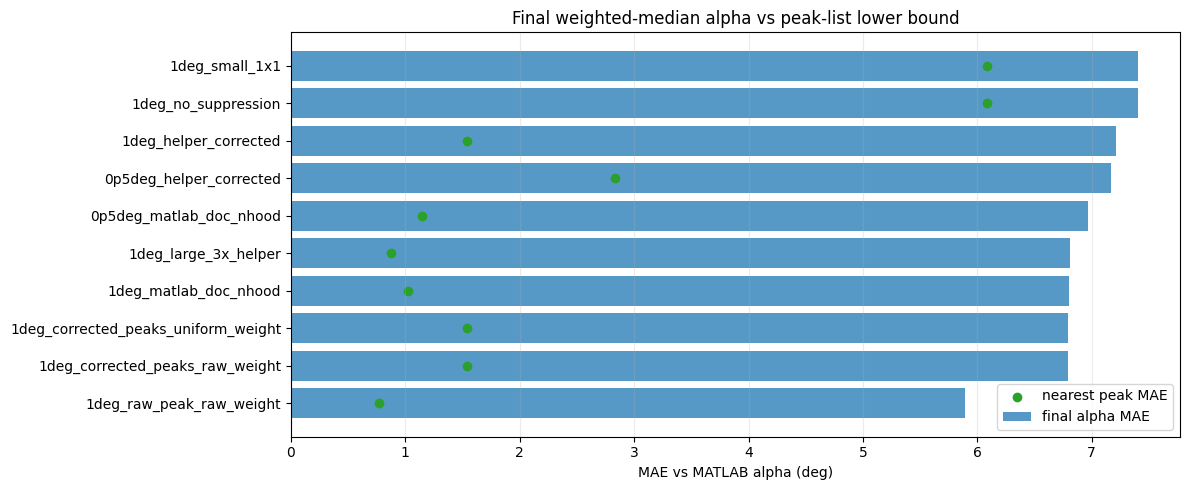

/var/folders/xv/1j8r4j6525v2s3svp0bnsy1w0000gn/T/ipykernel_36995/1566432194.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=order, vert=False, showfliers=False)


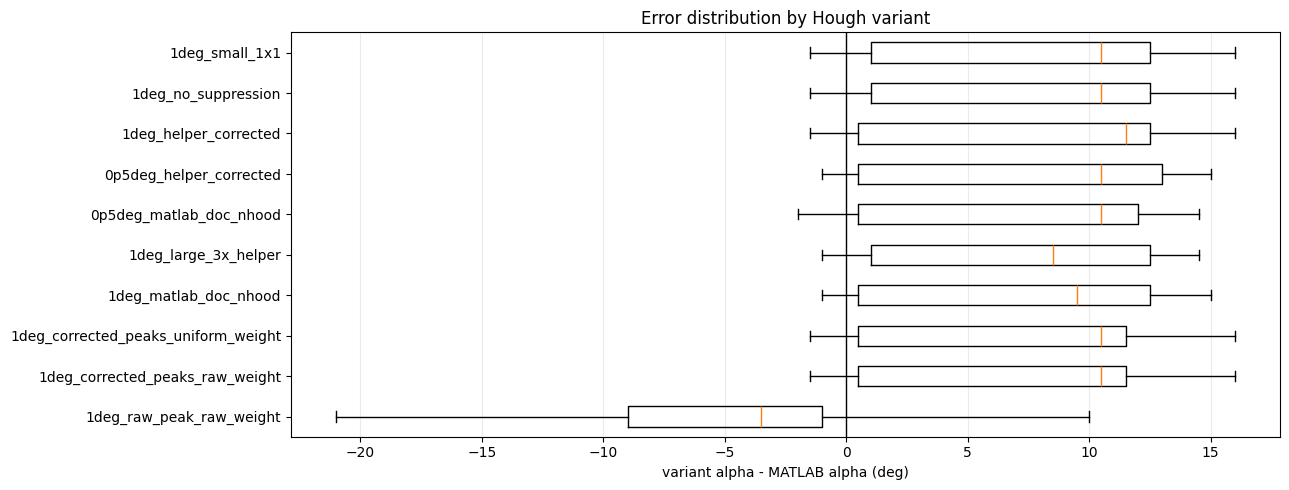

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_summary = summary.sort_values("alpha_mae", ascending=True)
ax.barh(plot_summary["variant"], plot_summary["alpha_mae"], color="tab:blue", alpha=0.75, label="final alpha MAE")
ax.scatter(plot_summary["nearest_peak_mae"], plot_summary["variant"], color="tab:green", label="nearest peak MAE")
ax.set_xlabel("MAE vs MATLAB alpha (deg)")
ax.set_title("Final weighted-median alpha vs peak-list lower bound")
ax.grid(True, axis="x", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
order = summary.sort_values("alpha_mae")["variant"].tolist()
box_data = [variant_df.loc[variant_df["variant"] == name, "variant_error"].dropna().to_numpy() for name in order]
ax.boxplot(box_data, labels=order, vert=False, showfliers=False)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("variant alpha - MATLAB alpha (deg)")
ax.set_title("Error distribution by Hough variant")
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

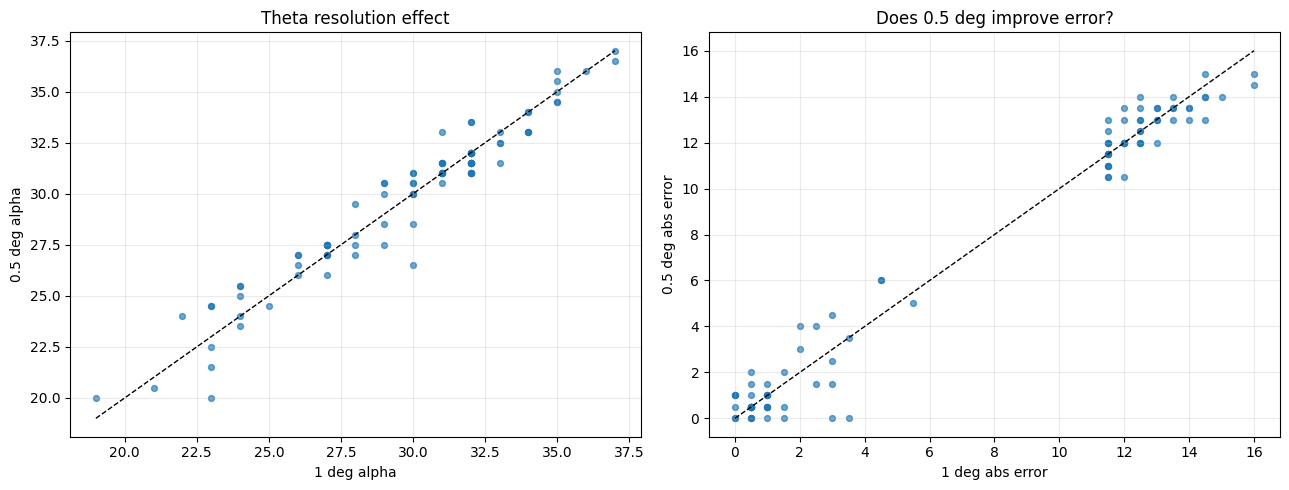

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

base = variant_df[variant_df["variant"] == "1deg_helper_corrected"].set_index("row")
half = variant_df[variant_df["variant"] == "0p5deg_helper_corrected"].set_index("row")
common = base.index.intersection(half.index)
axes[0].scatter(base.loc[common, "variant_alpha"], half.loc[common, "variant_alpha"], s=18, alpha=0.65)
lo = np.nanmin([base.loc[common, "variant_alpha"].min(), half.loc[common, "variant_alpha"].min()])
hi = np.nanmax([base.loc[common, "variant_alpha"].max(), half.loc[common, "variant_alpha"].max()])
axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_xlabel("1 deg alpha")
axes[0].set_ylabel("0.5 deg alpha")
axes[0].set_title("Theta resolution effect")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(base.loc[common, "abs_variant_error"], half.loc[common, "abs_variant_error"], s=18, alpha=0.65)
hi2 = np.nanmax([base.loc[common, "abs_variant_error"].max(), half.loc[common, "abs_variant_error"].max()])
axes[1].plot([0, hi2], [0, hi2], "k--", linewidth=1)
axes[1].set_xlabel("1 deg abs error")
axes[1].set_ylabel("0.5 deg abs error")
axes[1].set_title("Does 0.5 deg improve error?")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Weighted median crossing plots

The weighted median is not the strongest peak. It is the first angle, after sorting by angle, where cumulative normalized weight reaches 0.5.

These plots show why a peak near MATLAB alpha can exist but the final alpha can still move higher.

In [10]:
def cumulative_weight_table(alphas, weights):
    alphas = np.asarray(alphas, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(alphas) & np.isfinite(weights) & (weights > 0)
    if not np.any(mask):
        return pd.DataFrame(columns=["alpha", "weight", "normalized_weight", "cumulative_weight"])
    a = alphas[mask]
    w = weights[mask]
    order = np.argsort(a, kind="mergesort")
    a = a[order]
    w = w[order]
    wn = w / w.sum()
    return pd.DataFrame({
        "alpha": a,
        "weight": w,
        "normalized_weight": wn,
        "cumulative_weight": np.cumsum(wn),
    })

base_variant = "1deg_helper_corrected"
best_variant = summary.iloc[0]["variant"]
interesting_rows = []

weighted_fail_rows = nb25.loc[selected_rows].query("category == 'peak exists, weighted median differs'").sort_values("abs_alpha_error", ascending=False)["row"].head(2).tolist()
nearest_fail_rows = nb25.loc[selected_rows].query("category == 'nearest Python peak also far'").sort_values("abs_alpha_error", ascending=False)["row"].head(1).tolist()
good_rows = nb25.loc[selected_rows].query("category == 'matched within 1 deg'").sort_values("abs_alpha_error")["row"].head(1).tolist()

for r in weighted_fail_rows + nearest_fail_rows + good_rows:
    if int(r) not in interesting_rows:
        interesting_rows.append(int(r))

print("Interesting rows:", interesting_rows)
display(nb25.loc[interesting_rows, ["row", "frame", "category", "matlab_alpha", "python_alpha", "abs_alpha_error", "py_nearest_peak_to_matlab", "py_nearest_peak_distance_to_matlab"]])

Interesting rows: [119, 2553, 120, 17]


,row,frame,category,matlab_alpha,python_alpha,abs_alpha_error,py_nearest_peak_to_matlab,py_nearest_peak_distance_to_matlab
119,119,119,"peak exists, weighted median differs",19.0,34.0,15.0,20.0,1.0
2553,2553,2553,"peak exists, weighted median differs",20.5,35.0,14.5,20.0,0.5
120,120,120,nearest Python peak also far,18.0,34.0,16.0,25.0,7.0
17,17,17,matched within 1 deg,19.0,19.0,0.0,19.0,0.0


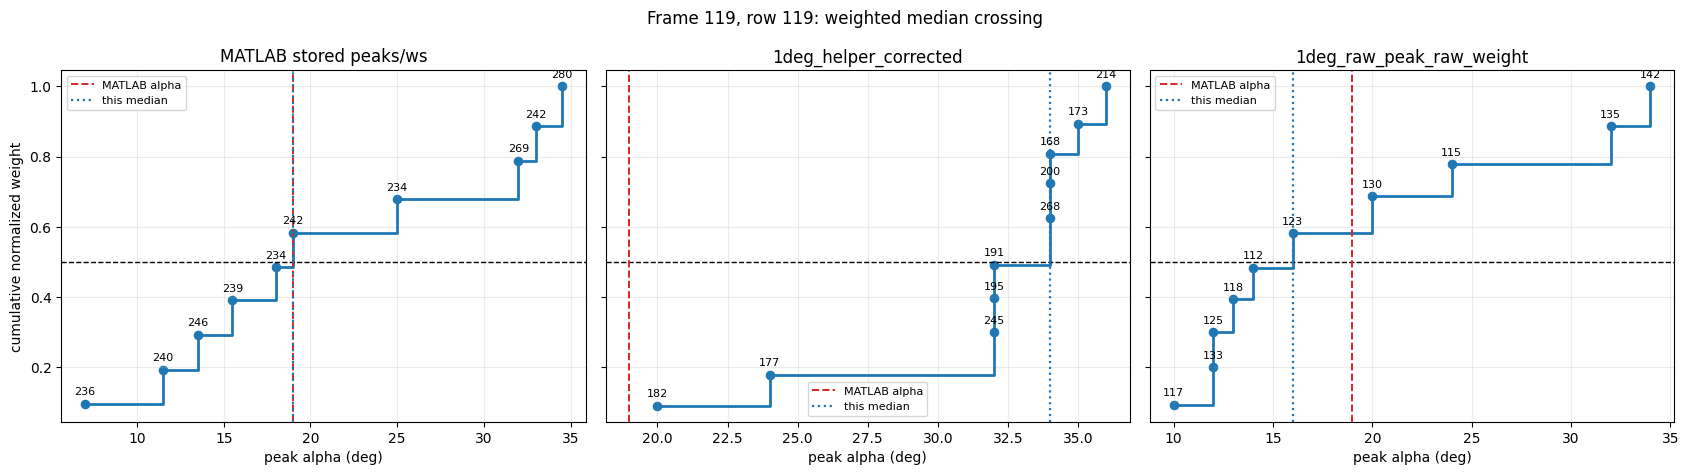

**Frame 119, row 119 peak tables**

,source,alpha,weight,normalized_weight,cumulative_weight,median_alpha
0,MATLAB stored peaks/ws,7.0,236.0,0.095857,0.095857,19.0
1,MATLAB stored peaks/ws,11.5,240.0,0.097482,0.193339,19.0
2,MATLAB stored peaks/ws,13.5,246.0,0.099919,0.293258,19.0
3,MATLAB stored peaks/ws,15.5,239.0,0.097076,0.390333,19.0
4,MATLAB stored peaks/ws,18.0,234.0,0.095045,0.485378,19.0
5,MATLAB stored peaks/ws,19.0,242.0,0.098294,0.583672,19.0
6,MATLAB stored peaks/ws,25.0,234.0,0.095045,0.678716,19.0
7,MATLAB stored peaks/ws,32.0,269.0,0.109261,0.787977,19.0
8,MATLAB stored peaks/ws,33.0,242.0,0.098294,0.886271,19.0
9,MATLAB stored peaks/ws,34.5,280.0,0.113729,1.000000,19.0


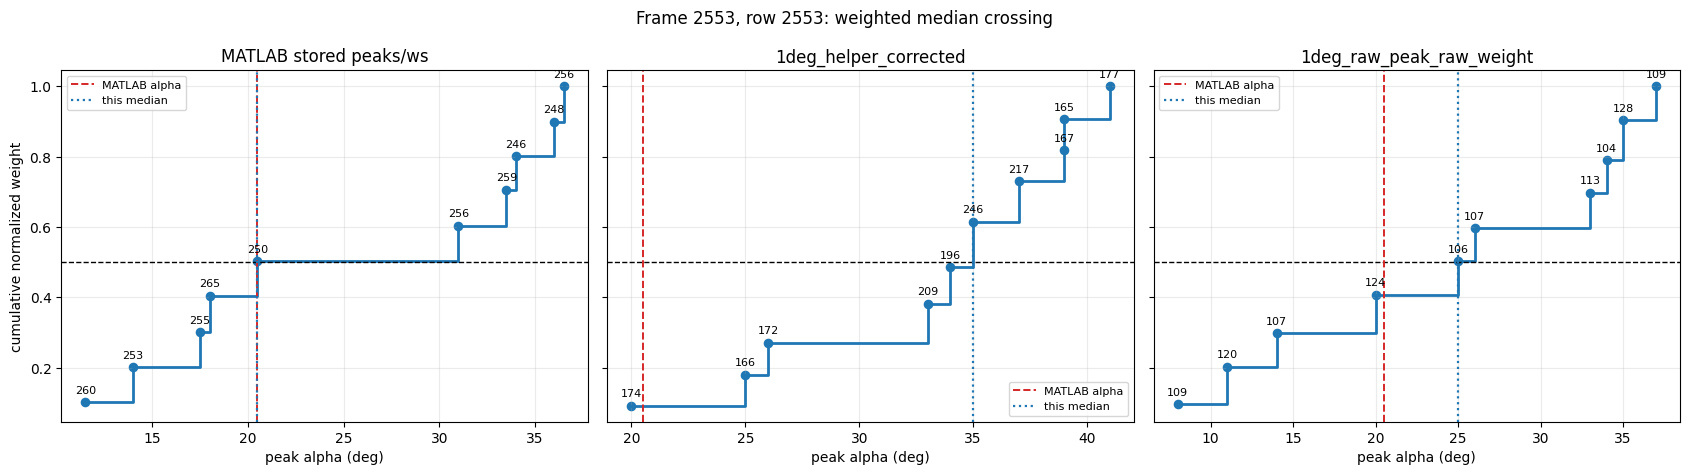

**Frame 2553, row 2553 peak tables**

,source,alpha,weight,normalized_weight,cumulative_weight,median_alpha
0,MATLAB stored peaks/ws,11.5,260.0,0.102041,0.102041,20.5
1,MATLAB stored peaks/ws,14.0,253.0,0.099294,0.201334,20.5
2,MATLAB stored peaks/ws,17.5,255.0,0.100078,0.301413,20.5
3,MATLAB stored peaks/ws,18.0,265.0,0.104003,0.405416,20.5
4,MATLAB stored peaks/ws,20.5,250.0,0.098116,0.503532,20.5
5,MATLAB stored peaks/ws,31.0,256.0,0.100471,0.604003,20.5
6,MATLAB stored peaks/ws,33.5,259.0,0.101648,0.705651,20.5
7,MATLAB stored peaks/ws,34.0,246.0,0.096546,0.802198,20.5
8,MATLAB stored peaks/ws,36.0,248.0,0.097331,0.899529,20.5
9,MATLAB stored peaks/ws,36.5,256.0,0.100471,1.000000,20.5


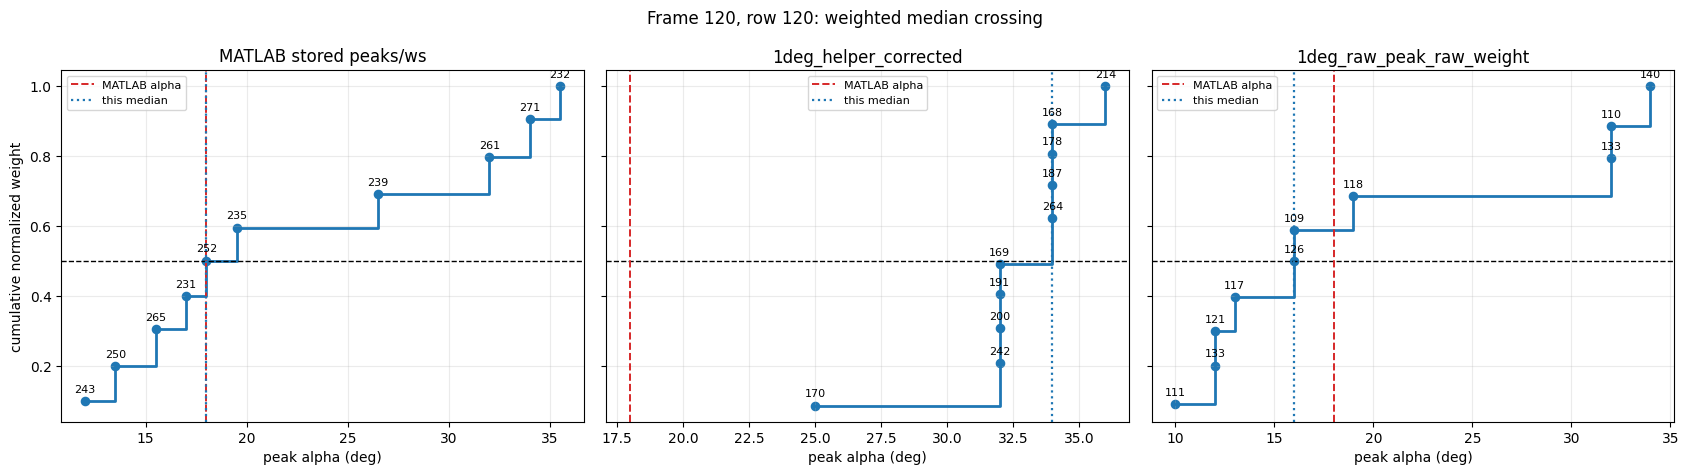

**Frame 120, row 120 peak tables**

,source,alpha,weight,normalized_weight,cumulative_weight,median_alpha
0,MATLAB stored peaks/ws,12.0,243.0,0.098023,0.098023,18.0
1,MATLAB stored peaks/ws,13.5,250.0,0.100847,0.198871,18.0
2,MATLAB stored peaks/ws,15.5,265.0,0.106898,0.305768,18.0
3,MATLAB stored peaks/ws,17.0,231.0,0.093183,0.398951,18.0
4,MATLAB stored peaks/ws,18.0,252.0,0.101654,0.500605,18.0
5,MATLAB stored peaks/ws,19.5,235.0,0.094796,0.595401,18.0
6,MATLAB stored peaks/ws,26.5,239.0,0.096410,0.691811,18.0
7,MATLAB stored peaks/ws,32.0,261.0,0.105284,0.797096,18.0
8,MATLAB stored peaks/ws,34.0,271.0,0.109318,0.906414,18.0
9,MATLAB stored peaks/ws,35.5,232.0,0.093586,1.000000,18.0


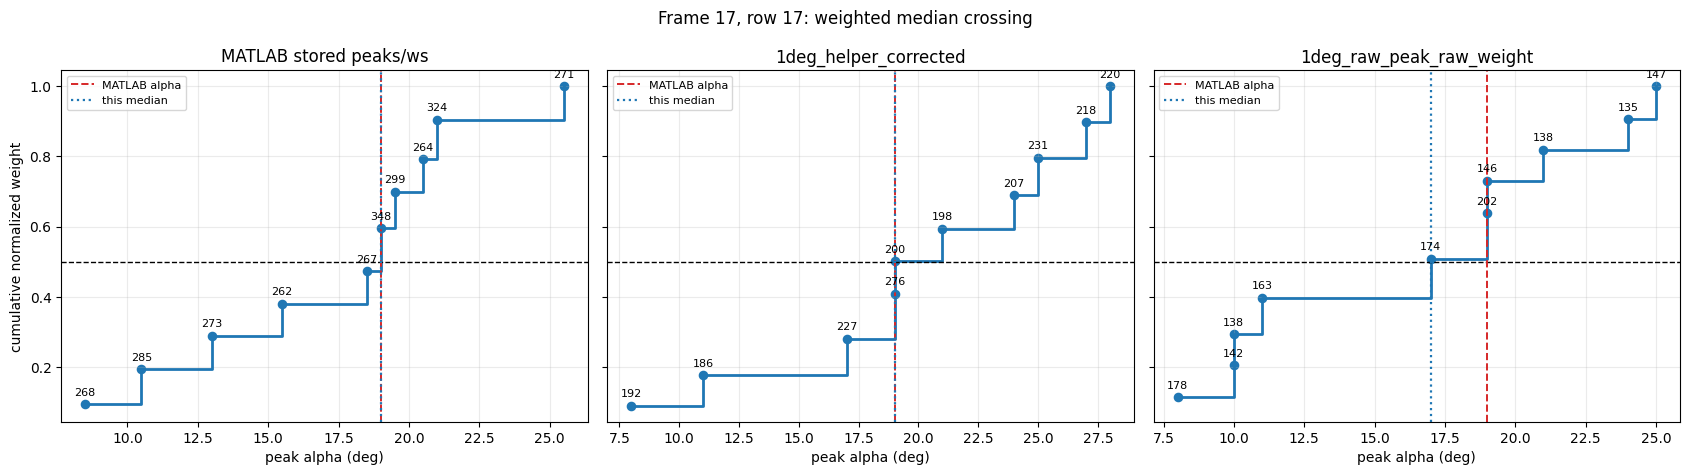

**Frame 17, row 17 peak tables**

,source,alpha,weight,normalized_weight,cumulative_weight,median_alpha
0,MATLAB stored peaks/ws,8.5,268.0,0.093674,0.093674,19.0
1,MATLAB stored peaks/ws,10.5,285.0,0.099616,0.193289,19.0
2,MATLAB stored peaks/ws,13.0,273.0,0.095421,0.288710,19.0
3,MATLAB stored peaks/ws,15.5,262.0,0.091576,0.380287,19.0
4,MATLAB stored peaks/ws,18.5,267.0,0.093324,0.473611,19.0
5,MATLAB stored peaks/ws,19.0,348.0,0.121636,0.595246,19.0
6,MATLAB stored peaks/ws,19.5,299.0,0.104509,0.699755,19.0
7,MATLAB stored peaks/ws,20.5,264.0,0.092275,0.792031,19.0
8,MATLAB stored peaks/ws,21.0,324.0,0.113247,0.905278,19.0
9,MATLAB stored peaks/ws,25.5,271.0,0.094722,1.000000,19.0


In [11]:
for row_idx in interesting_rows:
    selected_i = int(np.where(selected_rows == row_idx)[0][0])
    frame_number = int(nb25.loc[row_idx, "frame"])

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
    specs = [
        ("MATLAB stored peaks/ws", mat_peak_alphas_all[row_idx], mat_peak_weights_all[row_idx], mat_alpha_all[row_idx]),
        (base_variant, peak_alpha_cube[selected_i, variant_names.index(base_variant)], peak_weight_cube[selected_i, variant_names.index(base_variant)], alpha_matrix[selected_i, variant_names.index(base_variant)]),
        (best_variant, peak_alpha_cube[selected_i, variant_names.index(best_variant)], peak_weight_cube[selected_i, variant_names.index(best_variant)], alpha_matrix[selected_i, variant_names.index(best_variant)]),
    ]

    for ax, (title, alphas, weights, alpha_estimate) in zip(axes, specs):
        tab = cumulative_weight_table(alphas, weights)
        if len(tab):
            ax.step(tab["alpha"], tab["cumulative_weight"], where="post", linewidth=2)
            ax.scatter(tab["alpha"], tab["cumulative_weight"], s=35)
            for _, rec in tab.iterrows():
                ax.text(rec["alpha"], rec["cumulative_weight"] + 0.025, f"{rec['weight']:.0f}", fontsize=8, ha="center")
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
        ax.axvline(mat_alpha_all[row_idx], color="tab:red", linestyle="--", linewidth=1.4, label="MATLAB alpha")
        ax.axvline(alpha_estimate, color="tab:blue", linestyle=":", linewidth=1.6, label="this median")
        ax.set_title(title)
        ax.set_xlabel("peak alpha (deg)")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("cumulative normalized weight")
    fig.suptitle(f"Frame {frame_number}, row {row_idx}: weighted median crossing")
    plt.tight_layout()
    plt.show()

    display(Markdown(f"**Frame {frame_number}, row {row_idx} peak tables**"))
    tables = []
    for title, alphas, weights, alpha_estimate in specs:
        tab = cumulative_weight_table(alphas, weights)
        tab.insert(0, "source", title)
        tab["median_alpha"] = alpha_estimate
        tables.append(tab)
    display(pd.concat(tables, ignore_index=True))

## 8. Hough profile and peak suppression on representative frames

This visualization uses the same current Python mask and shows how different peak suppression choices sample the same Hough profile.

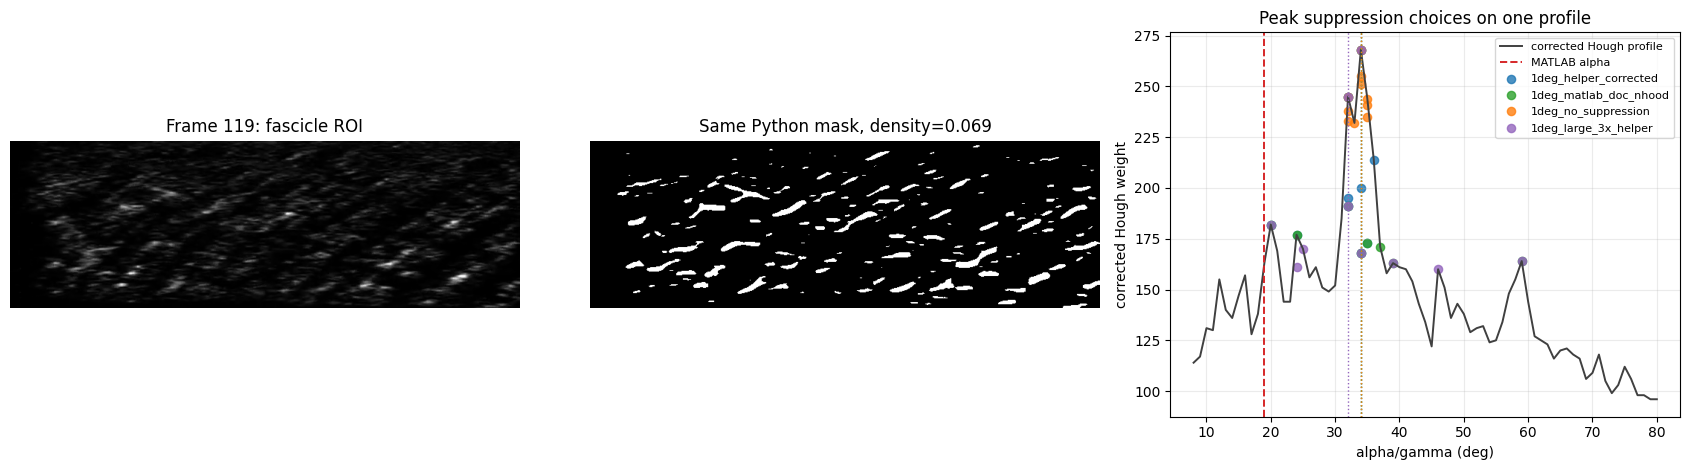

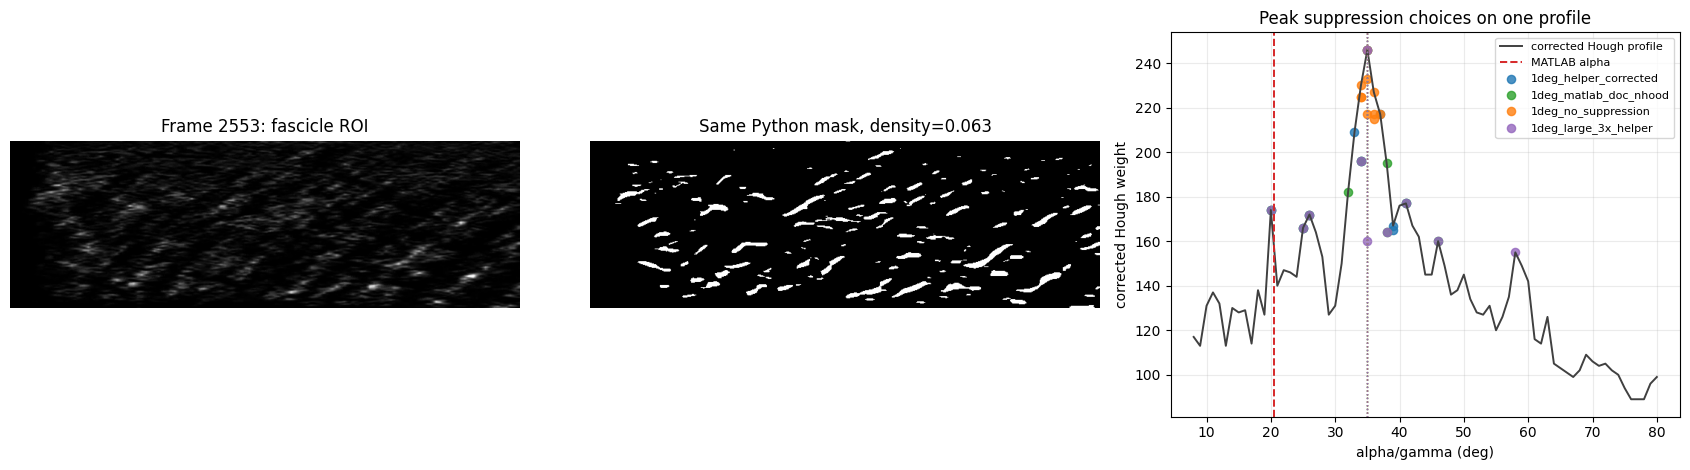

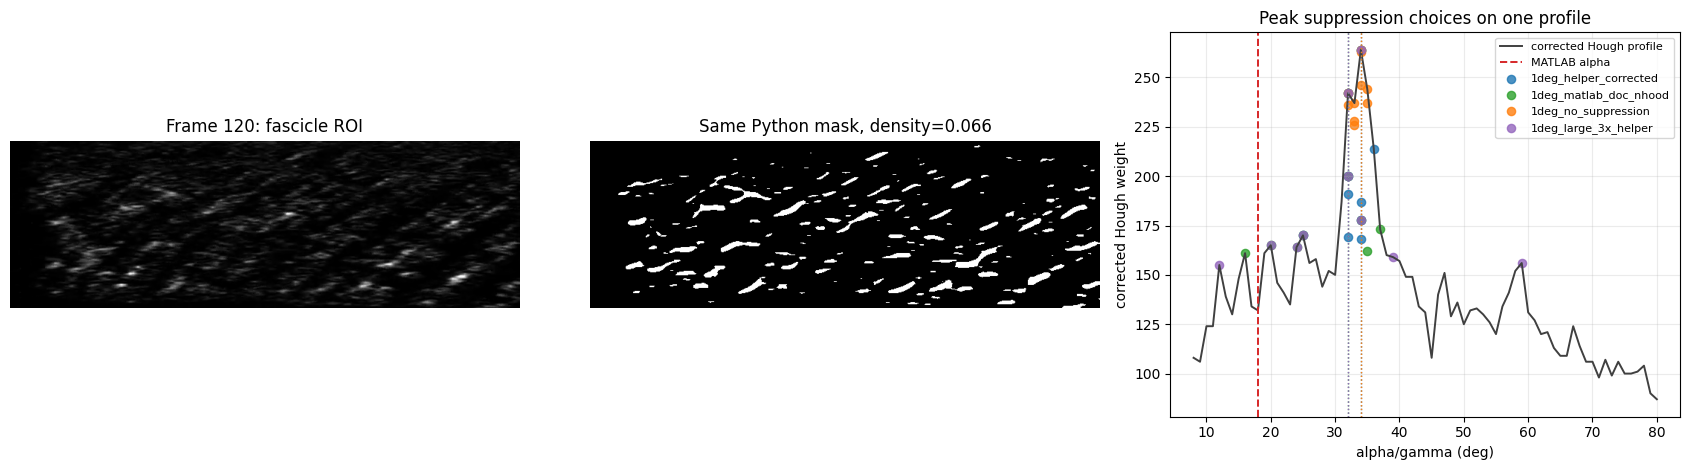

In [12]:
def sort_profile(gamma, values):
    gamma = np.asarray(gamma, dtype=float)
    values = np.asarray(values, dtype=float)
    order = np.argsort(gamma)
    return gamma[order], values[order]

profile_rows = interesting_rows[:3]
for row_idx in profile_rows:
    frame_number = int(nb25.loc[row_idx, "frame"])
    frame_gray = read_gray_frame(VIDEO_PATH, frame_number)
    fas_img = roi.extract_roi(frame_gray, rois["fascicle"])
    vesselness = fas_frangi_detector.get_vesselness_map(fas_img)
    binary = vesselness >= fas_frangi_detector.threshold
    core = hough_core(binary, params_by_theta[1.0])
    gamma, profile = sort_profile(core["gamma"], core["h_by_angle"])

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    axes[0].imshow(fas_img, cmap="gray")
    axes[0].set_title(f"Frame {frame_number}: fascicle ROI")
    axes[0].axis("off")

    axes[1].imshow(binary, cmap="gray")
    axes[1].set_title(f"Same Python mask, density={binary.mean():.3f}")
    axes[1].axis("off")

    axes[2].plot(gamma, profile, color="0.25", linewidth=1.4, label="corrected Hough profile")
    axes[2].axvline(mat_alpha_all[row_idx], color="tab:red", linestyle="--", linewidth=1.4, label="MATLAB alpha")

    selected_i = int(np.where(selected_rows == row_idx)[0][0])
    colors = {
        "1deg_helper_corrected": "tab:blue",
        "1deg_matlab_doc_nhood": "tab:green",
        "1deg_no_suppression": "tab:orange",
        "1deg_large_3x_helper": "tab:purple",
    }
    for name, color in colors.items():
        j = variant_names.index(name)
        a = peak_alpha_cube[selected_i, j]
        w = peak_weight_cube[selected_i, j]
        m = np.isfinite(a) & np.isfinite(w)
        axes[2].scatter(a[m], w[m], s=35, alpha=0.8, label=name, color=color)
        axes[2].axvline(alpha_matrix[selected_i, j], color=color, linestyle=":", linewidth=1)

    axes[2].set_xlabel("alpha/gamma (deg)")
    axes[2].set_ylabel("corrected Hough weight")
    axes[2].set_title("Peak suppression choices on one profile")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. What this notebook says to do next

Read the summary table first.

- If `0p5deg_*` improves only a little, theta resolution is not the main problem.
- If a wider suppression neighborhood improves the median, then the Python `hough_peaks` default neighborhood should be corrected before changing masks.
- If raw weights improve substantially, then the ellipse/radius correction or rounding order is suspect.
- If uniform weights improve, then the right angle is present but the accumulator weights are over-favoring higher angle bins.
- If none of these improves enough, the current Python mask is still the wrong input and the next notebook should port MATLAB's mask generation more exactly.